/tmp/ipykernel_20511/302700515.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GOOG", start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Dataset shape: (3773, 1)
Train: (2970, 60, 1) Test: (743, 60, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 0.0014 - val_loss: 4.3400e-04
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 2.6347e-04 - val_loss: 4.3557e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 2.6595e-04 - val_loss: 2.9326e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 2.2022e-04 - val_loss: 4.7118e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 2.1840e-04 - val_loss: 2.8860e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 1.8385e-04 - val_loss: 0.0010
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 1.6947e-04 - val_loss: 0.0021
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 1.8349e-04 - val_loss: 4.1768e-04
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 1.6617e-04 - val_loss: 0.0012
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 1.6015e-04 - val_loss: 9.2064e-04
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
RMSE: 7.62982222691761
MAE : 6.2142962818992

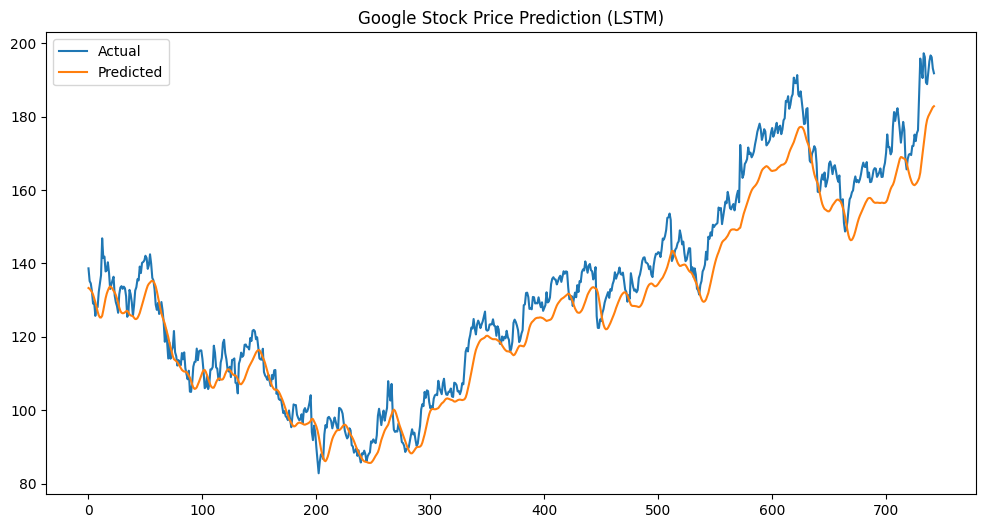

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Next Day Closing Price: 182.80604553222656


In [1]:
# ===============================
# GOOGLE STOCK LSTM - ONE CELL
# ===============================

!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1️⃣ Download Google stock data
data = yf.download("GOOG", start="2010-01-01", end="2024-12-31")
data = data[['Close']]
print("Dataset shape:", data.shape)

# 2️⃣ Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data.values)

# 3️⃣ Create sequences (60 days → next day)
window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 4️⃣ Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, "Test:", X_test.shape)

# 5️⃣ Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 6️⃣ Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# 7️⃣ Predict
predicted_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_scaled)
real_prices = scaler.inverse_transform(y_test.reshape(-1,1))

# 8️⃣ Evaluate
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))
mae = mean_absolute_error(real_prices, predicted_prices)
print("RMSE:", rmse)
print("MAE :", mae)

# 9️⃣ Plot results
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Actual")
plt.plot(predicted_prices, label="Predicted")
plt.title("Google Stock Price Prediction (LSTM)")
plt.legend()
plt.show()

# 🔮 Predict next day price
last_60_days = scaled_data[-60:].reshape(1,60,1)
next_day_scaled = model.predict(last_60_days)
next_day_price = scaler.inverse_transform(next_day_scaled)
print("Predicted Next Day Closing Price:", float(next_day_price[0][0]))